# Predição de Volatilidade — ^BVSP
Organização do fluxo: dados, features, modelagem, avaliação e predições recentes.

In [918]:
from warnings import filterwarnings
filterwarnings("ignore")
from dataclasses import dataclass
from typing import List
from yfinance import download
from datetime import datetime, timedelta
from numpy import where, nan
from pandas import DataFrame
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from datetime import date
import pandas as pd
pd.set_option('display.max_colwidth', None)  # Exibe texto completo sem truncar
pd.set_option('display.width', None)         # Largura automática
pd.set_option('display.max_columns', None)   # Mostra todas as colunas

## 1) Configuração e Coleta de Dados
Definição de parâmetros e download da série histórica.

In [919]:
param = {
    'ticker': '^BVSP',
    'interval': '1d',
    'start': '2013-01-01',
    'end': '2023-12-31',
    'last_data': (datetime.now() + timedelta(days=20)).strftime('%Y-%m-%d'),
    'column': 'Close'
}

df = download(
    param['ticker'], 
    start=param['start'], 
    end=param['end'], 
    interval=param['interval'], 
    progress=False, 
    auto_adjust=False
).droplevel(1, axis=1).reset_index()
df.columns.name = None

print(f"Dados carregados: {len(df)} registros de {df['Date'].iloc[0].strftime('%d/%m/%Y')} a {df['Date'].iloc[-1].strftime('%d/%m/%Y')}")


Dados carregados: 2724 registros de 02/01/2013 a 28/12/2023


In [920]:
df.tail(3)

,Date,Adj Close,Close,High,Low,Open,Volume
2721,2023-12-26,133533.0,133533.0,133645.0,132753.0,132753.0,0
2722,2023-12-27,134194.0,134194.0,134195.0,133328.0,133523.0,6168200
2723,2023-12-28,134185.0,134185.0,134392.0,133832.0,134194.0,7812700


## 2) Preparação dos Dados e Alvo
Cálculo de retorno, volatilidade, alvo futuro e datas-alvo.

In [921]:
@dataclass
class ConfigVolatilidade:
    """Configuração para cálculo de volatilidade."""
    janela_sd: int = 21
    horizonte: int = 21 
    coluna_preco: str = 'Close'


class PreparacaoDosDados:
    """Prepara dados para predição de volatilidade."""

    def __init__(self, df: DataFrame, config: ConfigVolatilidade = None):
        self.df = df.copy()  # Não modifica original
        self.config = config or ConfigVolatilidade()
        self._validar_colunas()

    def _validar_colunas(self):
        if self.config.coluna_preco not in self.df.columns:
            raise ValueError(f"Coluna '{self.config.coluna_preco}' não encontrada")

    def _retorno(self) -> 'PreparacaoDosDados':
        self.df['ret'] = self.df[self.config.coluna_preco].pct_change(1)
        return self

    def _desvio_padrao(self) -> 'PreparacaoDosDados':
        self.df['sd'] = self.df['ret'].rolling(self.config.janela_sd).std()
        return self

    def _alvo(self) -> 'PreparacaoDosDados':
        h = self.config.horizonte
        self.df['sd_alvo'] = self.df['sd'].shift(-h)
        self.df['var_alvo'] = self.df['sd_alvo'] - self.df['sd']
        
        # Lógica: se sd_alvo = NaN então bin_alvo = NaN
        self.df['bin_alvo'] = where(
            self.df['sd_alvo'].isna(), 
            nan, 
            where(self.df['var_alvo'] > 0, 1, 0)
        )
        
        # Date alvo: shift e preenchimento sequencial das datas faltantes (dias úteis)
        self.df['date_alvo'] = self.df['Date'].shift(-h)
        mask_faltante = self.df['date_alvo'].isna()

        if mask_faltante.any():
            qtd_faltantes = int(mask_faltante.sum())

            if (~mask_faltante).any():
                data_inicio = self.df.loc[~mask_faltante, 'date_alvo'].iloc[-1] + pd.offsets.BDay(1)
            else:
                data_inicio = self.df['Date'].iloc[-1] + pd.offsets.BDay(1)

            datas_futuras = pd.bdate_range(start=data_inicio, periods=qtd_faltantes)
            self.df.loc[mask_faltante, 'date_alvo'] = datas_futuras.to_numpy()

        return self

    def preparar(self, dropna: bool = True) -> DataFrame:
        """Pipeline completo de preparação."""
        self._retorno()._desvio_padrao()._alvo()
        
        if dropna:
            self.df = self.df # .dropna()
        
        return self.df

    @property
    def features(self) -> list:
        """Retorna lista de features calculadas."""
        return ['ret', 'sd']

    @property  
    def target(self) -> str:
        """Retorna nome da coluna alvo."""
        return 'bin_alvo'

In [922]:
# Uso simples (valores padrão: janela_sd=21, horizonte=21)
prep = PreparacaoDosDados(df)
df_preparado = prep.preparar()

print(f"Shape: {df_preparado.shape}")

df_preparado = df_preparado.copy()

# Coluna explicativa com data do alvo
df_preparado['alvo_logica'] = df_preparado.apply(
    lambda row: (
        'NaN = sd_alvo não disponível (sem dados futuros)'
        if pd.isna(row['bin_alvo'])
        else f"1 = Para {row['date_alvo'].strftime('%d/%m/%Y')} espera-se ALTA da volatilidade (SD futuro > SD atual)"
        if row['bin_alvo'] == 1
        else f"0 = Para {row['date_alvo'].strftime('%d/%m/%Y')} espera-se QUEDA da volatilidade (SD futuro <= SD atual)"
    ),
    axis=1
)

cols = ["Date", "ret", "sd", "sd_alvo", "var_alvo", "bin_alvo", "date_alvo",	"alvo_logica"]
df_preparado[cols].tail(25)

Shape: (2724, 13)


,Date,ret,sd,sd_alvo,var_alvo,bin_alvo,date_alvo,alvo_logica
2699,2023-11-23,0.004292,0.010302,0.008518,-0.001784,0.0,2023-12-22,0 = Para 22/12/2023 espera-se QUEDA da volatilidade (SD futuro <= SD atual)
2700,2023-11-24,-0.008169,0.010696,0.008200,-0.002496,0.0,2023-12-26,0 = Para 26/12/2023 espera-se QUEDA da volatilidade (SD futuro <= SD atual)
2701,2023-11-27,0.001123,0.010319,0.008199,-0.002119,0.0,2023-12-27,0 = Para 27/12/2023 espera-se QUEDA da volatilidade (SD futuro <= SD atual)
2702,2023-11-28,0.006803,0.009954,0.008184,-0.001770,0.0,2023-12-28,0 = Para 28/12/2023 espera-se QUEDA da volatilidade (SD futuro <= SD atual)
2703,2023-11-29,-0.003454,0.009315,NaN,NaN,NaN,2023-12-29,NaN = sd_alvo não disponível (sem dados futuros)
2704,2023-11-30,0.009754,0.008947,NaN,NaN,NaN,2024-01-01,NaN = sd_alvo não disponível (sem dados futuros)
2705,2023-12-01,0.006063,0.008946,NaN,NaN,NaN,2024-01-02,NaN = sd_alvo não disponível (sem dados futuros)
2706,2023-12-04,-0.010148,0.009238,NaN,NaN,NaN,2024-01-03,NaN = sd_alvo não disponível (sem dados futuros)
2707,2023-12-05,0.000789,0.007717,NaN,NaN,NaN,2024-01-04,NaN = sd_alvo não disponível (sem dados futuros)
2708,2023-12-06,-0.010086,0.008263,NaN,NaN,NaN,2024-01-05,NaN = sd_alvo não disponível (sem dados futuros)


## 3) Visualização da Volatilidade
Comparação entre volatilidade atual e futura no horizonte definido.

In [923]:
# Gráfico Volatilidade: Atual vs Futuro (21 dias)
df_plot = df_preparado.tail(30).copy()

fig1 = go.Figure()

# Volatilidade atual
fig1.add_trace(go.Scatter(
    x=df_plot['Date'],
    y=df_plot['sd'],
    mode='lines',
    name='Volatilidade Atual',
    line=dict(color='#1f77b4', width=2.5),
    hovertemplate='<b>%{x|%d/%m/%Y}</b><br>Atual: %{y:.5f}<extra></extra>'
))

# Volatilidade futura (21 dias à frente)
fig1.add_trace(go.Scatter(
    x=df_plot['Date'],
    y=df_plot['sd_alvo'],
    mode='lines',
    name='Volatilidade Futura (21d)',
    line=dict(color='#ff7f0e', width=2, dash='dot'),
    fill='tonexty',
    fillcolor='rgba(255, 127, 14, 0.10)',
    hovertemplate='<b>%{x|%d/%m/%Y}</b><br>Futura: %{y:.5f}<extra></extra>'
))

# Último ponto
ultimo = df_plot.iloc[-1]
fig1.add_trace(go.Scatter(
    x=[ultimo['Date'], ultimo['Date']],
    y=[ultimo['sd'], ultimo['sd_alvo']],
    mode='markers',
    name='Último',
    marker=dict(size=9, color=['#1f77b4', '#ff7f0e'], line=dict(color='white', width=1.5)),
    showlegend=False,
    hovertemplate='<b>Último: %{y:.5f}</b><extra></extra>'
))

fig1.update_layout(
    title='Volatilidade: Atual vs Futura (21 dias à frente)',
    template='plotly_white',
    hovermode='x unified',
    height=420,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(l=50, r=30, t=70, b=40)
)

fig1.update_yaxes(title='Volatilidade')
fig1.update_xaxes(title='Data')

fig1.show()

## 4) Engenharia de Features
Criação das variáveis explicativas para o modelo.

In [924]:
@dataclass
class ConfigFeatures:
    """Configuração para engenharia de features."""
    janela_curta: int = 5
    janela_media: int = 21


class FeatureEngineering:
    """Engenharia de features para predição de volatilidade."""

    def __init__(self, df: DataFrame, config: ConfigFeatures = None):
        self.df = df.copy()
        self.config = config or ConfigFeatures()
        self._features_criadas: List[str] = []

    def feature1(self) -> 'FeatureEngineering':
        jc = self.config.janela_curta
        col = 'feature1'
        sd = self.df['sd']
        vo = self.df['Volume']

        Q = lambda x, t: x.rolling(t).sum()
        W = lambda x, t: x.rolling(t).max()
        E = lambda x, t: x.rolling(t).min()
        R = lambda x, t: x.rolling(t).std()

        q = (vo - E(vo, 8)) / (W(vo, 8) - E(vo, 8))
        w = 1 / (1 - q * sd)
        e = (sd.diff() * W(w, 5)) 

        self.df[col] = e
        self._features_criadas.append(col)
        
        return self
    
    def adicionar_todas(self) -> DataFrame:
        return (self
            .feature1()
            .df)

    @property
    def features(self) -> List[str]:
        """Lista de features criadas."""
        return self._features_criadas.copy()

In [925]:
# Feature Engineering
fe = FeatureEngineering(df_preparado)
df_features = fe.adicionar_todas()

print(f"Features criadas: {fe.features}")
print(f"Shape final: {df_features.shape}")

# df_features.tail(23)

Features criadas: ['feature1']
Shape final: (2724, 15)


## 5) Análise Exploratória das Features
Visualização temporal e correlação das features com o alvo futuro.

In [926]:
# Visualização Profissional de Todas as Features
feature_cols = fe.features

# Configuração de cores por feature
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

# Criar subplots
fig = make_subplots(
    rows=len(feature_cols), 
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    subplot_titles=[f"<b>{col}</b>" for col in feature_cols],
    specs=[[{"secondary_y": False}] for _ in feature_cols]
)

# Preparar dados
df_plot = df_features.copy()
if 'Date' not in df_plot.columns:
    df_plot = df_plot.reset_index()

# Adicionar traces
for i, col in enumerate(feature_cols, 1):
    cor = cores[i % len(cores)]
    
    # Estatísticas da feature
    valores = df_plot[col].dropna()
    media = valores.mean()
    std = valores.std()
    
    # Linha da série
    fig.add_trace(
        go.Scatter(
            x=df_plot['Date'],
            y=df_plot[col],
            mode='lines',
            name=col,
            line=dict(color=cor, width=1.8),
            hovertemplate=(
                f'<b>{col}</b><br>' +
                'Data: %{x|%d/%m/%Y}<br>' +
                'Valor: %{y:.5f}<br>' +
                '<extra></extra>'
            ),
            showlegend=False
        ),
        row=i,
        col=1
    )
    
    # Linha da média
    fig.add_hline(
        y=media,
        line_dash="dash",
        line_color="gray",
        line_width=1,
        opacity=0.5,
        row=i,
        col=1,
        annotation_text=f"μ={media:.5f}",
        annotation_position="right",
        annotation_font_size=9,
        annotation_font_color="gray"
    )
    
    # Atualizar eixo Y de cada subplot
    fig.update_yaxes(
        title_text=col,
        title_font=dict(size=10),
        row=i,
        col=1
    )

# Layout geral
fig.update_layout(
    title={
        'text': f'<b>Análise de Features: {len(feature_cols)} Variáveis ao Longo do Tempo</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16}
    },
    template='plotly_white',
    hovermode='x unified',
    height=max(600, len(feature_cols) * 180),
    showlegend=False,
    margin=dict(l=80, r=100, t=80, b=60)
)

# Atualizar eixo X apenas no último subplot
fig.update_xaxes(
    title_text='Data',
    title_font=dict(size=12),
    row=len(feature_cols),
    col=1
)

fig.show()

# Resumo estatístico
print(f"\n{'='*80}")
print(f"📊 RESUMO ESTATÍSTICO DAS FEATURES")
print(f"{'='*80}")
for col in feature_cols:
    valores = df_plot[col].dropna()
    print(f"\n{col}:")
    print(f"   Média: {valores.mean():.6f}")
    print(f"   Desvio: {valores.std():.6f}")
    print(f"   Min: {valores.min():.6f} | Max: {valores.max():.6f}")
    print(f"   Últimos 5 valores: {valores.tail().values}")


📊 RESUMO ESTATÍSTICO DAS FEATURES

feature1:
   Média: -0.000000
   Desvio: 0.000956
   Min: -0.012072 | Max: 0.011044
   Últimos 5 valores: [ 2.06350330e-04  3.22144504e-07 -3.19124894e-04 -6.83260391e-07
 -1.58036028e-05]


In [927]:
# Correlação Profissional: Features vs Volatilidade Futura
df_clean = df_features.dropna()
feature_cols = fe.features

# Configuração
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
n_features = len(feature_cols)

# Criar subplots (1 linha, n colunas)
fig = make_subplots(
    rows=1, 
    cols=n_features,
    shared_yaxes=True,
    subplot_titles=[f"<b>{col}</b>" for col in feature_cols],
    horizontal_spacing=0.04,
    vertical_spacing=0.02
)

# Target
y = df_clean['sd_alvo']

# Adicionar scatter plots
for i, col in enumerate(feature_cols, 1):
    x = df_clean[col]
    cor_atual = cores[i % len(cores)]
    
    # Calcular correlação
    corr = x.corr(y)
    corr_emoji = "🟢" if abs(corr) > 0.5 else "🟡" if abs(corr) > 0.3 else "🔴"
    
    # Scatter plot
    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode='markers',
            name=col,
            marker=dict(
                color=cor_atual,
                size=6,
                opacity=0.5,
                line=dict(width=0.5, color='white')
            ),
            customdata=df_clean[['Date']].values,
            hovertemplate=(
                f'<b>{col}</b><br>' +
                'Feature: %{x:.5f}<br>' +
                'Vol. Futura: %{y:.5f}<br>' +
                'Data: %{customdata[0]|%d/%m/%Y}' +
                '<extra></extra>'
            ),
            showlegend=False
        ),
        row=1,
        col=i
    )
    
    # Linha de tendência (regressão linear aproximada)
    from numpy import polyfit, poly1d
    if len(x.dropna()) > 1:
        z = polyfit(x, y, 1)
        p = poly1d(z)
        x_sorted = sorted(x)
        
        fig.add_trace(
            go.Scatter(
                x=x_sorted,
                y=p(x_sorted),
                mode='lines',
                name='Tendência',
                line=dict(color=cor_atual, width=2, dash='dash'),
                showlegend=False,
                hoverinfo='skip'
            ),
            row=1,
            col=i
        )
    
    # Atualizar eixo X
    fig.update_xaxes(
        title_text=f"<b>{col}</b><br><i>r = {corr:.3f} {corr_emoji}</i>",
        title_font=dict(size=10),
        row=1,
        col=i,
        showgrid=True,
        gridwidth=1,
        gridcolor='rgba(200,200,200,0.3)'
    )

# Atualizar apenas o primeiro eixo Y
fig.update_yaxes(
    title_text='<b>Volatilidade Futura (sd_alvo)</b>',
    title_font=dict(size=11),
    row=1,
    col=1,
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(200,200,200,0.3)'
)

# Layout geral
fig.update_layout(
    title={
        'text': f'<b>Análise de Correlação: Features vs Volatilidade Futura</b><br><sub>🟢 Alta (|r|>0.5) | 🟡 Média (|r|>0.3) | 🔴 Baixa</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16}
    },
    template='plotly_white',
    height=450,
    showlegend=False,
    margin=dict(l=80, r=40, t=100, b=80),
    hovermode='closest'
)

fig.show()

# Tabela de correlações
print(f"\n{'='*80}")
print(f"📊 TABELA DE CORRELAÇÕES (Pearson)")
print(f"{'='*80}")
correlacoes = []
for col in feature_cols:
    corr = df_clean[col].corr(df_clean['sd_alvo'])
    interpretacao = "🟢 Forte" if abs(corr) > 0.5 else "🟡 Moderada" if abs(corr) > 0.3 else "🔴 Fraca"
    correlacoes.append({'Feature': col, 'Correlação': f"{corr:+.4f}", 'Força': interpretacao})
    print(f"   {col:25s} | r = {corr:+.4f}  {interpretacao}")

# Ordenar por correlação absoluta
print(f"\n{'='*80}")
print(f"🏆 RANKING POR CORRELAÇÃO ABSOLUTA")
print(f"{'='*80}")
correlacoes_sorted = sorted(correlacoes, key=lambda x: abs(float(x['Correlação'])), reverse=True)
for rank, item in enumerate(correlacoes_sorted, 1):
    print(f"   {rank}º {item['Feature']:25s} | r = {item['Correlação']}  {item['Força']}")


📊 TABELA DE CORRELAÇÕES (Pearson)
   feature1                  | r = +0.1703  🔴 Fraca

🏆 RANKING POR CORRELAÇÃO ABSOLUTA
   1º feature1                  | r = +0.1703  🔴 Fraca


## 6) Treinamento e Avaliação do Modelo
Split temporal, treino, matriz de confusão e métricas de classificação.

In [928]:
# Preparação dos dados para modelagem
df_model = df_features.dropna().reset_index()
vars_modelo = fe.features

# Split temporal 50/50
split_idx = int(len(df_model) / 2)

df_treino = df_model.iloc[:split_idx]
df_teste = df_model.iloc[split_idx:]

x_treino = df_treino[vars_modelo]
y_treino = df_treino['bin_alvo']

x_teste = df_teste[vars_modelo]
y_teste = df_teste['bin_alvo']

print(f"Treino: {len(df_treino)} registros | Teste: {len(df_teste)} registros")
print(f"Features: {vars_modelo}")

Treino: 1339 registros | Teste: 1339 registros
Features: ['feature1']


In [929]:
# Treinamento do modelo
modelo = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
modelo.fit(x_treino, y_treino)

# Predições
y_pred_treino = modelo.predict(x_treino)
y_pred_teste = modelo.predict(x_teste)

print("Distribuição das predições:")
for nome, pred in {"Treino": y_pred_treino, "Teste": y_pred_teste}.items():
    print(f"\n{nome}:")
    print(f"  Classe 0: {list(pred).count(0)}")
    print(f"  Classe 1: {list(pred).count(1)}")

Distribuição das predições:

Treino:
  Classe 0: 623
  Classe 1: 716

Teste:
  Classe 0: 616
  Classe 1: 723


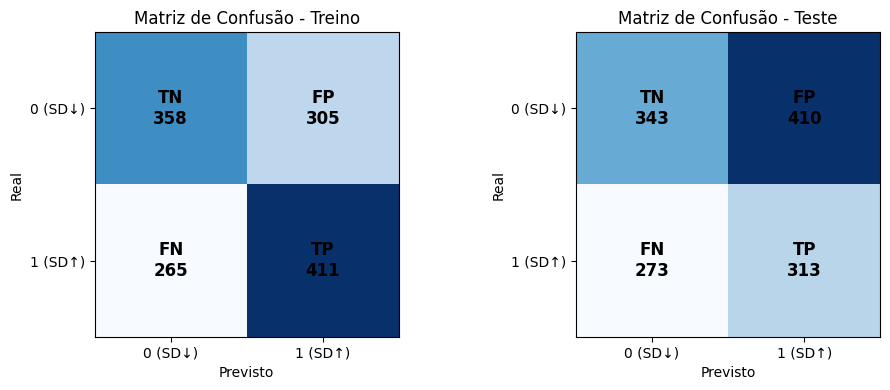

In [930]:
# Matriz de Confusão
cm_treino = confusion_matrix(y_treino, y_pred_treino)
cm_teste = confusion_matrix(y_teste, y_pred_teste)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = {(0, 0): "TN", (0, 1): "FP", (1, 0): "FN", (1, 1): "TP"}

for ax, (nome, cm) in zip(axes, {"Treino": cm_treino, "Teste": cm_teste}.items()):
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f"Matriz de Confusão - {nome}")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0 (SD↓)", "1 (SD↑)"])
    ax.set_yticklabels(["0 (SD↓)", "1 (SD↑)"])
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[(i, j)]}\n{cm[i, j]}", ha="center", va="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [931]:
# Métricas
print("=" * 50)
print("MÉTRICAS DE AVALIAÇÃO")
print("=" * 50)

# Acurácia
acc_treino = accuracy_score(y_treino, y_pred_treino)
acc_teste = accuracy_score(y_teste, y_pred_teste)
print(f"\nAcurácia Treino: {acc_treino:.2%}")
print(f"Acurácia Teste:  {acc_teste:.2%}")

# AUC
proba_treino = modelo.predict_proba(x_treino)[:, 1]
proba_teste = modelo.predict_proba(x_teste)[:, 1]
auc_treino = roc_auc_score(y_treino, proba_treino)
auc_teste = roc_auc_score(y_teste, proba_teste)
print(f"\nAUC Treino: {auc_treino:.2%}")
print(f"AUC Teste:  {auc_teste:.2%}")

MÉTRICAS DE AVALIAÇÃO

Acurácia Treino: 57.43%
Acurácia Teste:  48.99%

AUC Treino: 60.47%
AUC Teste:  50.35%


In [932]:
# Classification Report
print("\n" + "=" * 50)
print("CLASSIFICATION REPORT - TREINO")
print("=" * 50)
print(classification_report(y_treino, y_pred_treino, target_names=["0 (SD↓)", "1 (SD↑)"]))

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT - TESTE")
print("=" * 50)
print(classification_report(y_teste, y_pred_teste, target_names=["0 (SD↓)", "1 (SD↑)"]))


CLASSIFICATION REPORT - TREINO
              precision    recall  f1-score   support

     0 (SD↓)       0.57      0.54      0.56       663
     1 (SD↑)       0.57      0.61      0.59       676

    accuracy                           0.57      1339
   macro avg       0.57      0.57      0.57      1339
weighted avg       0.57      0.57      0.57      1339


CLASSIFICATION REPORT - TESTE
              precision    recall  f1-score   support

     0 (SD↓)       0.56      0.46      0.50       753
     1 (SD↑)       0.43      0.53      0.48       586

    accuracy                           0.49      1339
   macro avg       0.49      0.49      0.49      1339
weighted avg       0.50      0.49      0.49      1339



## 7) Deploy e Predições Recentes
Geração de predições para dados mais recentes e montagem do painel final.

In [933]:
# Download dados recentes
df_deploy = download(
    param['ticker'], 
    start=param['end'], 
    end=param['last_data'],
    interval=param['interval'], 
    progress=False, 
    auto_adjust=False
).droplevel(1, axis=1).reset_index()
df_deploy.columns.name = None

# Preparação
prep_deploy = PreparacaoDosDados(df_deploy)
df_deploy_prep = prep_deploy.preparar()

# Feature Engineering
fe_deploy = FeatureEngineering(df_deploy_prep)
df_deploy_final = fe_deploy.adicionar_todas()

# Predição
x_deploy = df_deploy_final[vars_modelo]
y_deploy = df_deploy_final['bin_alvo']
y_pred_deploy = modelo.predict(x_deploy)
df_deploy_final['pred'] = y_pred_deploy

# Tratando NaNs no alvo (últimos 21 dias não têm alvo definido)
df_deploy_final.loc[df_deploy_final['sd_alvo'].isna(), 'bin_alvo'] = nan

# Lógica textual do alvo observado e da predição
def _texto_logica(bin_valor, data_alvo):
    if pd.isna(bin_valor):
        return 'NaN = sd_alvo não disponível (sem dados futuros)'
    if bin_valor == 1:
        return f"1 = Para {data_alvo.strftime('%d/%m/%Y')} espera-se ALTA da volatilidade (SD futuro > SD atual)"
    return f"0 = Para {data_alvo.strftime('%d/%m/%Y')} espera-se QUEDA da volatilidade (SD futuro <= SD atual)"

df_deploy_final['alvo_logica'] = df_deploy_final.apply(
    lambda row: _texto_logica(row['bin_alvo'], row['date_alvo']),
    axis=1
)

df_deploy_final['pred_logica'] = df_deploy_final.apply(
    lambda row: _texto_logica(row['pred'], row['date_alvo'])
    if pd.notna(row['date_alvo']) else 'NaN = sd_alvo não disponível (sem dados futuros)',
    axis=1
)

print(f"Dados deploy: {len(df_deploy_final)} registros")
print(f"Acurácia deploy: {accuracy_score(y_deploy.dropna(), y_pred_deploy[:len(y_deploy.dropna())]):.2%}")

df_deploy_final[[
    'Date', 'sd', 'sd_alvo',
    'bin_alvo', 'date_alvo', 'pred', 'alvo_logica', 'pred_logica'
]].tail(40)

Dados deploy: 536 registros
Acurácia deploy: 47.38%


,Date,sd,sd_alvo,bin_alvo,date_alvo,pred,alvo_logica,pred_logica
496,2025-12-22,0.013568,0.010833,0.0,2026-01-26,1.0,0 = Para 26/01/2026 espera-se QUEDA da volatilidade (SD futuro <= SD atual),1 = Para 26/01/2026 espera-se ALTA da volatilidade (SD futuro > SD atual)
497,2025-12-23,0.013881,0.010987,0.0,2026-01-27,0.0,0 = Para 27/01/2026 espera-se QUEDA da volatilidade (SD futuro <= SD atual),0 = Para 27/01/2026 espera-se QUEDA da volatilidade (SD futuro <= SD atual)
498,2025-12-26,0.013872,0.011136,0.0,2026-01-28,1.0,0 = Para 28/01/2026 espera-se QUEDA da volatilidade (SD futuro <= SD atual),1 = Para 28/01/2026 espera-se ALTA da volatilidade (SD futuro > SD atual)
499,2025-12-29,0.013438,0.011449,0.0,2026-01-29,0.0,0 = Para 29/01/2026 espera-se QUEDA da volatilidade (SD futuro <= SD atual),0 = Para 29/01/2026 espera-se QUEDA da volatilidade (SD futuro <= SD atual)
500,2025-12-30,0.013445,0.011967,0.0,2026-01-30,1.0,0 = Para 30/01/2026 espera-se QUEDA da volatilidade (SD futuro <= SD atual),1 = Para 30/01/2026 espera-se ALTA da volatilidade (SD futuro > SD atual)
501,2026-01-02,0.013447,0.011779,0.0,2026-02-02,1.0,0 = Para 02/02/2026 espera-se QUEDA da volatilidade (SD futuro <= SD atual),1 = Para 02/02/2026 espera-se ALTA da volatilidade (SD futuro > SD atual)
502,2026-01-05,0.013527,0.011955,0.0,2026-02-03,1.0,0 = Para 03/02/2026 espera-se QUEDA da volatilidade (SD futuro <= SD atual),1 = Para 03/02/2026 espera-se ALTA da volatilidade (SD futuro > SD atual)
503,2026-01-06,0.013316,0.013363,1.0,2026-02-04,1.0,1 = Para 04/02/2026 espera-se ALTA da volatilidade (SD futuro > SD atual),1 = Para 04/02/2026 espera-se ALTA da volatilidade (SD futuro > SD atual)
504,2026-01-07,0.013509,0.012912,0.0,2026-02-05,0.0,0 = Para 05/02/2026 espera-se QUEDA da volatilidade (SD futuro <= SD atual),0 = Para 05/02/2026 espera-se QUEDA da volatilidade (SD futuro <= SD atual)
505,2026-01-08,0.013047,0.012914,0.0,2026-02-06,0.0,0 = Para 06/02/2026 espera-se QUEDA da volatilidade (SD futuro <= SD atual),0 = Para 06/02/2026 espera-se QUEDA da volatilidade (SD futuro <= SD atual)


- predict(X) retorna a classe final (no seu caso 0 ou 1).
- predict_proba(X) retorna as probabilidades por classe para cada linha.
- Em classificação binária, o resultado costuma vir como duas colunas: [P(classe 0), P(classe 1)].
- Por isso você usa [:, 1] para pegar a probabilidade de “ALTA” (classe 1).

In [934]:
# Visualização profissional e simples das últimas predições
n_ultimas = 30

df_vis = df_deploy_final.copy()
df_vis = df_vis[df_vis['pred'].notna()].tail(n_ultimas).copy()

# Probabilidade da classe 1 (ALTA) para hover explicativo
proba_alta = modelo.predict_proba(df_vis[vars_modelo])[:, 1]
df_vis['proba_alta'] = proba_alta
df_vis['proba_queda'] = 1 - df_vis['proba_alta']

# Labels de predição e observado
df_vis['pred_label'] = df_vis['pred'].map({1: 'ALTA esperada', 0: 'QUEDA esperada'})
df_vis['pred_cor'] = df_vis['pred'].map({1: '#2ca02c', 0: '#d62728'})
df_vis['real_label'] = df_vis['bin_alvo'].map({1: 'ALTA observada', 0: 'QUEDA observada'}).fillna('Sem observação futura')

# Indicativo de acerto/erro quando já existe dado futuro
df_vis['status_pred'] = where(
    df_vis['bin_alvo'].isna(),
    '⏳ Pendente (sem dado futuro)',
    where(df_vis['pred'] == df_vis['bin_alvo'], '✅ Acerto', '❌ Erro')
)

fig_pred = go.Figure()

# Linha de referência da volatilidade atual
fig_pred.add_trace(go.Scatter(
    x=df_vis['date_alvo'],
    y=df_vis['sd'],
    mode='lines',
    name='SD atual',
    line=dict(color='#1f77b4', width=2),
    hovertemplate=
        '<b>Data alvo: %{x|%d/%m/%Y}</b><br>'
        + 'SD atual: %{y:.5f}<extra></extra>'
))

# Pontos de predição com hover explicativo
fig_pred.add_trace(go.Scatter(
    x=df_vis['date_alvo'],
    y=df_vis['sd'],
    mode='markers',
    name='Predição',
    marker=dict(
        size=11,
        color=df_vis['pred_cor'],
        line=dict(color='white', width=1)
    ),
    customdata=df_vis[[
        'Date',
        'pred_label',
        'real_label',
        'status_pred',
        'proba_alta',
        'proba_queda',
        'pred_logica'
    ]],
    hovertemplate=
        '<b>Data alvo: %{x|%d/%m/%Y}</b><br>'
        + 'Data base: %{customdata[0]|%d/%m/%Y}<br>'
        + 'Predição: %{customdata[1]}<br>'
        + 'Real (se disponível): %{customdata[2]}<br>'
        + '<b>Status: %{customdata[3]}</b><br>'
        + 'Prob. ALTA: %{customdata[4]:.1%}<br>'
        + 'Prob. QUEDA: %{customdata[5]:.1%}<br>'
        + '<br><i>%{customdata[6]}</i>'
        + '<extra></extra>'
))

fig_pred.update_layout(
    title=f'Últimas {len(df_vis)} predições de volatilidade',
    xaxis_title='Data alvo (horizonte da predição)',
    yaxis_title='Volatilidade (SD)',
    template='plotly_white',
    legend_title='Séries',
    hovermode='closest',
    height=520
)

fig_pred.update_xaxes(showgrid=True)
fig_pred.update_yaxes(showgrid=True)

fig_pred.show()